In [1]:
import dplpy as dpl
import pandas as pd
# Reading data from files

# Reading from different formats produce same dataframe
ca533 = dpl.readers("../tests/data/rwl/ca533.rwl")
ca533csv = dpl.readers("../tests/data/csv/ca533.csv")
print(ca533.equals(ca533csv))

# Can specify whether file has headers so reading is done appropriately
ca667 = dpl.readers("../tests/data/rwl/ca667.rwl", header=True)
print(ca667)

ca533.rwl successfully extracted as rwl file with 34 series covering the period from 626 to 1983
ca533.csv successfully extracted as csv file with 34 series covering the period from 626 to 1983
True


ca667.rwl successfully extracted as rwl file with 310 series covering the period from -2649 to 2005 (auto-detected 3 header lines)
  1 series combined from non-overlapping duplicate IDs (merged segments):
    ST850A: 2 segments spanning -662 to 453
       SS004B  SL009A  ST860B  SS024B  SL004B  SG067A  SN151A  SL166B  SS004A  \
Year                                                                            
-2649    0.68    0.28    0.43    0.47    0.64    0.40    0.69    0.56    0.62   
-2648    0.63    0.38    0.45    0.43    0.51    0.22    0.73    0.46    0.50   
-2647    0.47    0.30    0.36    0.16    0.33    0.16    0.43    0.36    0.36   
-2646    0.62    0.33    0.45    0.31    0.68    0.29    0.61    0.46    0.67   
-2645    0.51    0.44    0.42    0.21    0.55    0.21    0.45    0.53    0.67   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
 2001     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
 2002     NaN     NaN 

In [2]:
print("Summary\n", dpl.summary(ca533), "\n")
print("Statistics\n", dpl.stats(ca533), "\n")

Summary
            CAM011      CAM021      CAM031      CAM032      CAM041      CAM042  \
count  454.000000  551.000000  628.000000  549.000000  301.000000  446.000000   
mean     0.439581    0.424465    0.349156    0.293224    0.525648    0.439148   
std      0.221801    0.185397    0.213666    0.162930    0.222568    0.347705   
min      0.000000    0.050000    0.000000    0.000000    0.100000    0.070000   
25%      0.290000    0.290000    0.180000    0.180000    0.350000    0.270000   
50%      0.400000    0.400000    0.290000    0.260000    0.530000    0.360000   
75%      0.540000    0.520000    0.510000    0.390000    0.680000    0.460000   
max      1.360000    1.110000    1.030000    0.850000    1.380000    3.030000   

           CAM051      CAM061      CAM062      CAM071  ...      CAM151  \
count  737.000000  627.000000  459.000000  947.000000  ...  749.000000   
mean     0.273012    0.462281    0.441939    0.249071  ...    0.445648   
std      0.139691    0.201785    0.1883

In [3]:
print("Report")
dpl.report(ca533)

Report


Number of dated series: 34
Number of measurements: 23276
Avg series length: 684.5882
Range: 1358
Span: 626 - 1983
Mean (Std dev) series intercorrelation: 0.629 (0.086)
Mean (Std dev) AR1: 0.7093 (0.0981)
-------------
Years with absent rings listed by series

      CAM011 -- 1753 1782
      CAM031 -- 1497 1500 1523 1533 1540 1542 1545 1578 1579 1580 1655 1668 1670 1681
      CAM032 -- 1497 1523 1579 1654 1670 1681 1782
      CAM051 -- 1475
      CAM061 -- 1497 1523 1542 1545 1547 1579 1654 1655 1668 1670 1672 1782 1858 1960
      CAM062 -- 1542 1545 1547 1548 1579 1654 1655 1670 1672 1782 1836 1857 1858 1929
      CAM071 -- 1269 1497 1498 1523 1542 1547 1578 1579 1612 1655 1656 1668 1670 1672 1674 1690 1707 1708 1756 1782 1795 1820 1836 1845 1857 1858 1924 1948 1960
      CAM072 -- 1218 1497 1498 1523 1533 1538 1542 1545 1546 1547 1571 1579 1580 1590 1654 1655 1668 1670 1672 1675 1690
      CAM081 -- 1218 1336
      CAM082 -- 1362 1858 1865
      CAM091 -- 1655 1669 1670 1782 1858
    

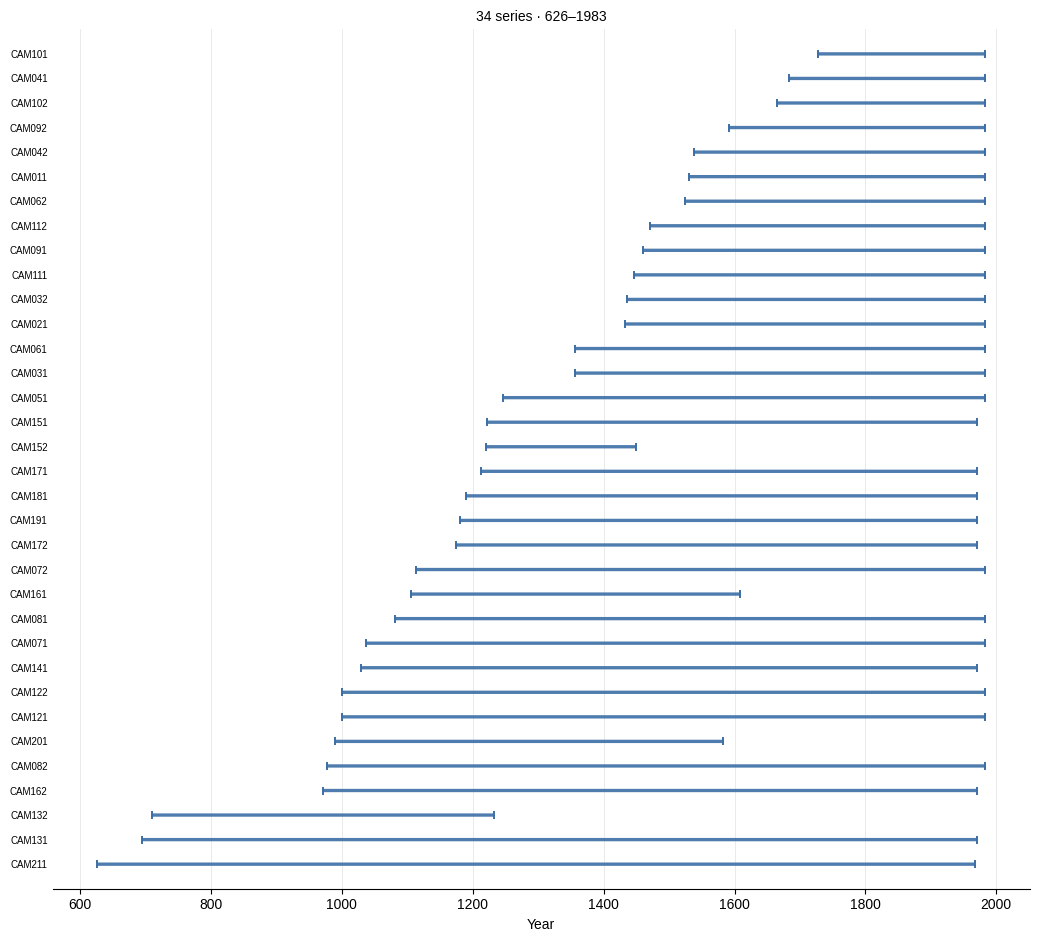

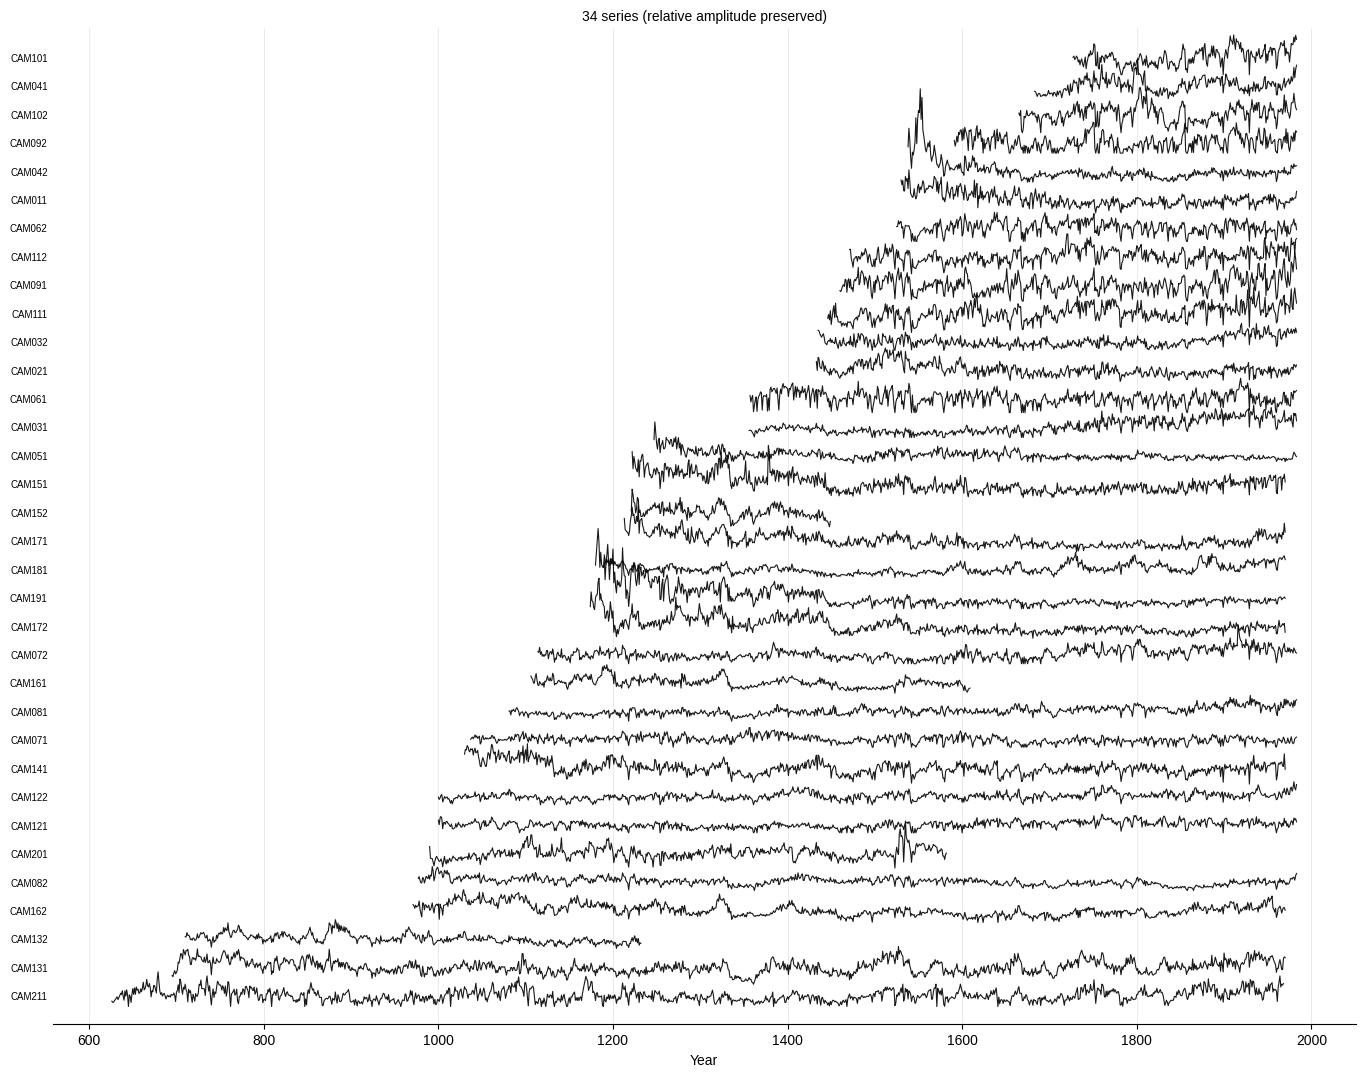

(<Figure size 1378.5x1088 with 1 Axes>,
 <Axes: title={'center': '34 series (relative amplitude preserved)'}, xlabel='Year'>)

In [4]:
dpl.plot(ca533, type="seg")
dpl.plot(ca533, type="spag")

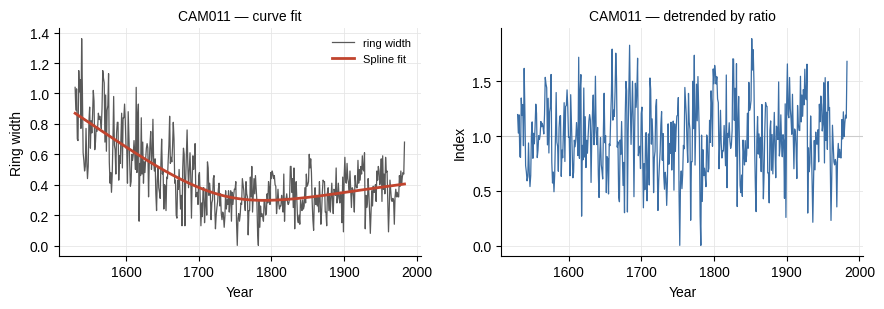

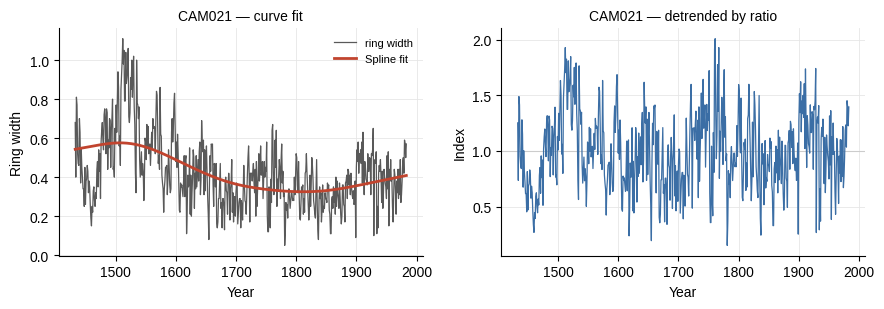

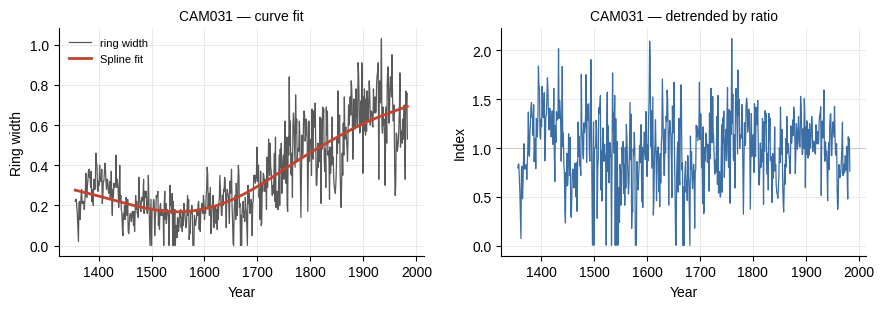

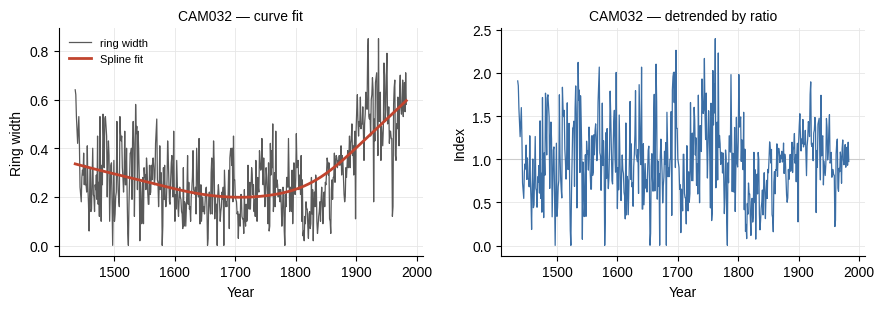

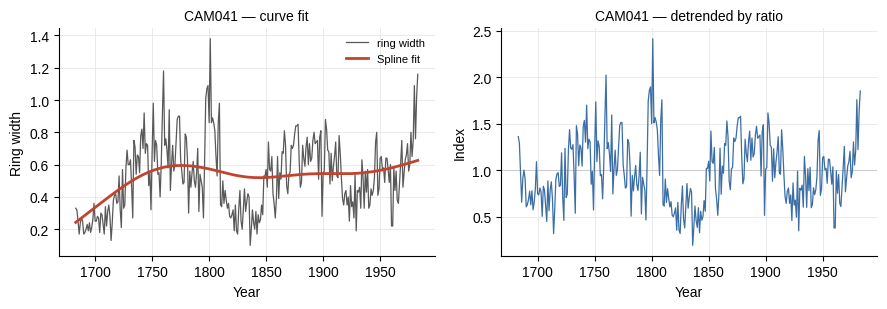

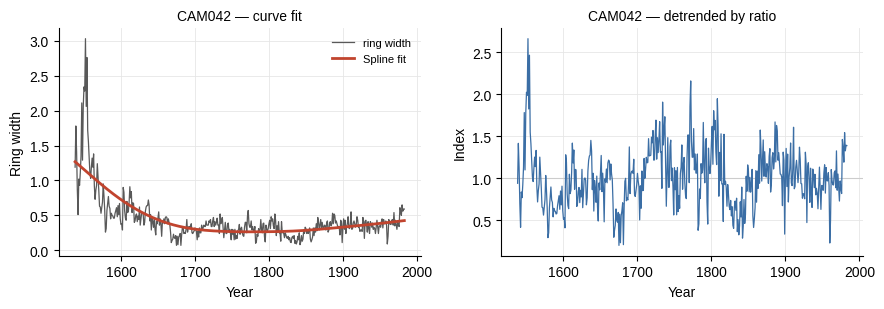

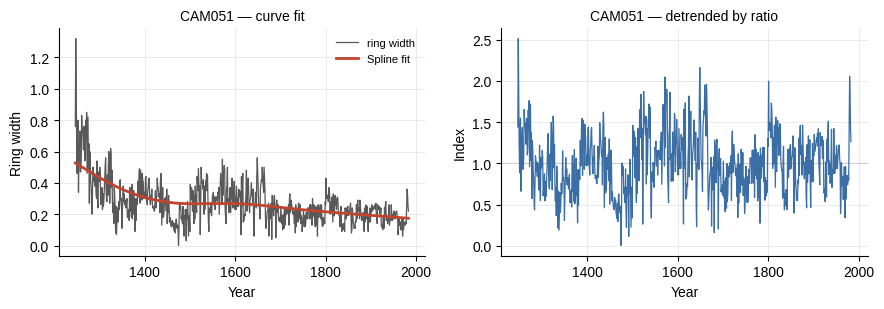

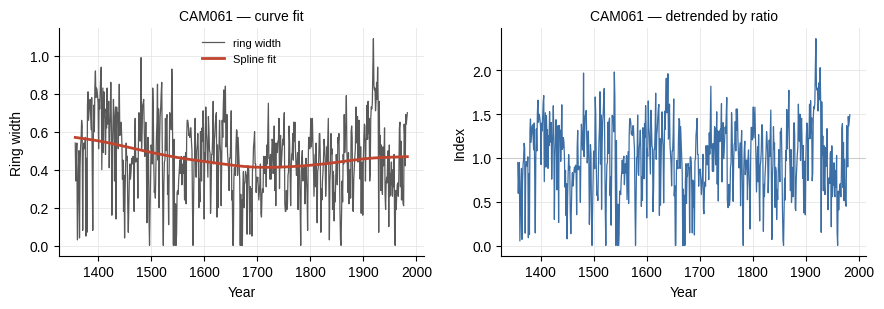

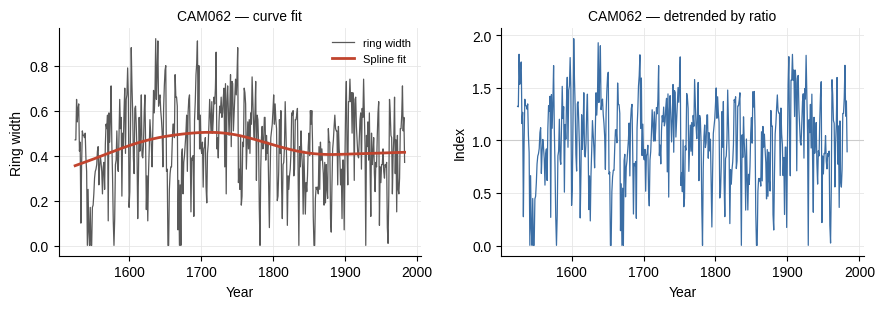

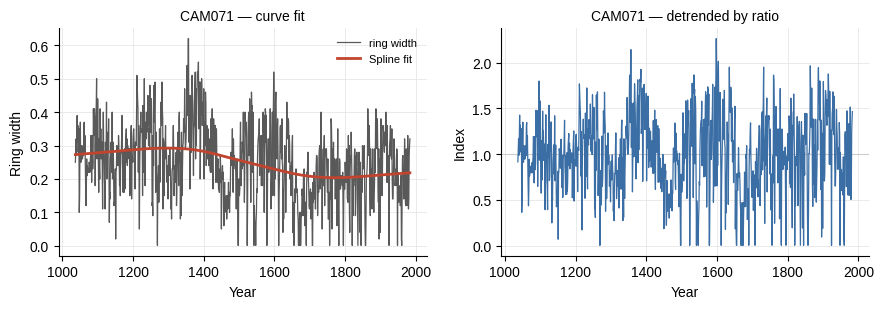

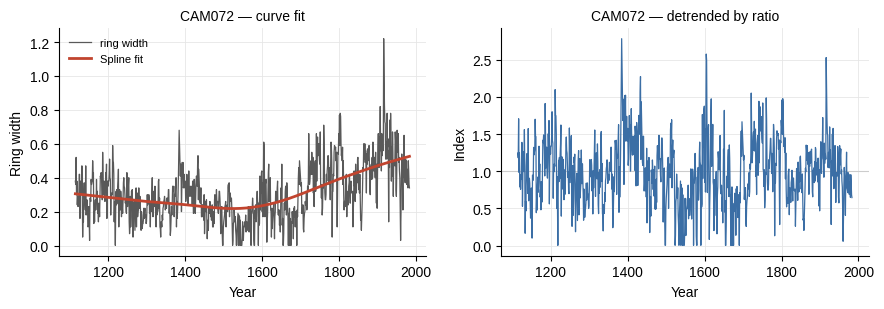

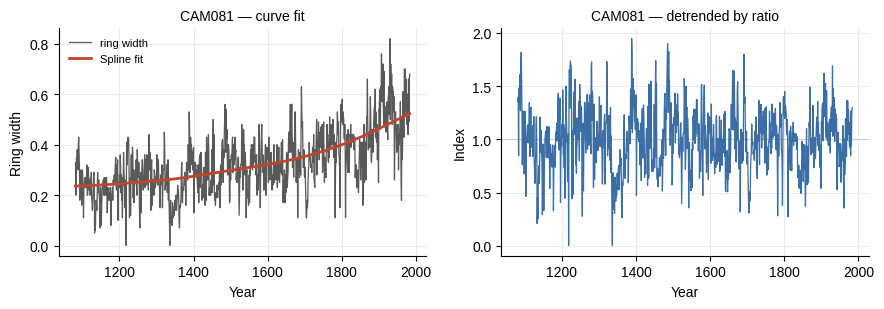

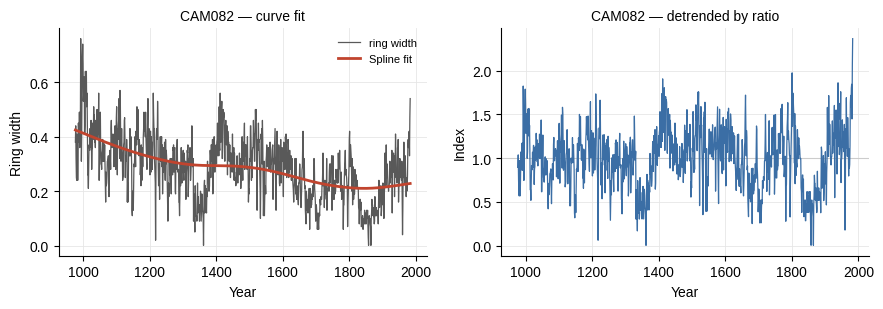

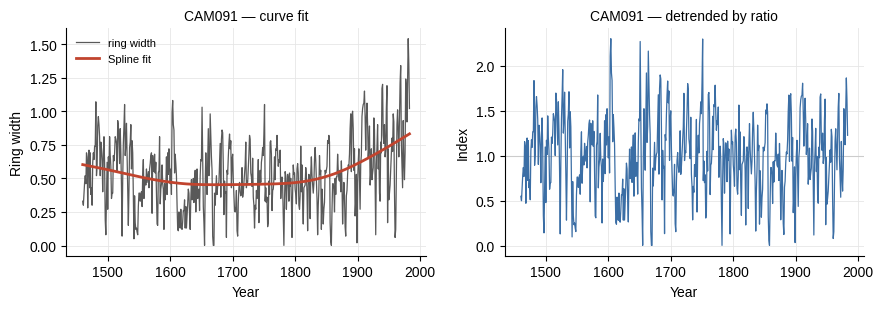

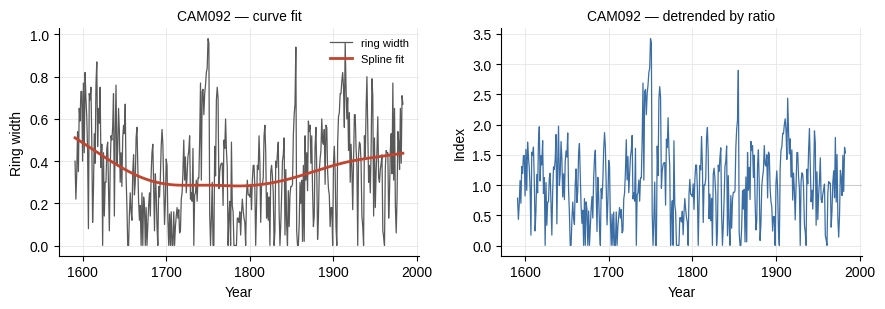

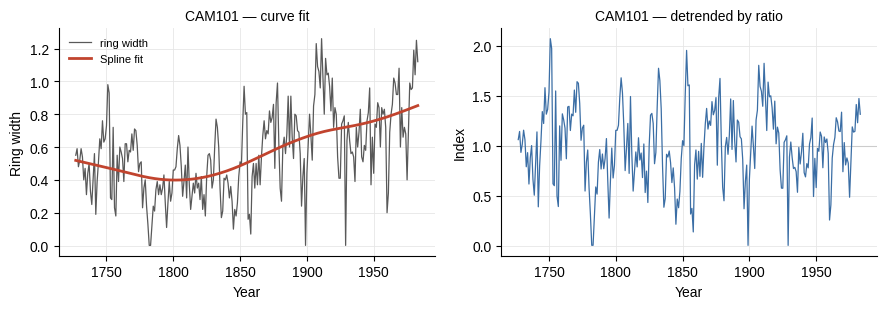

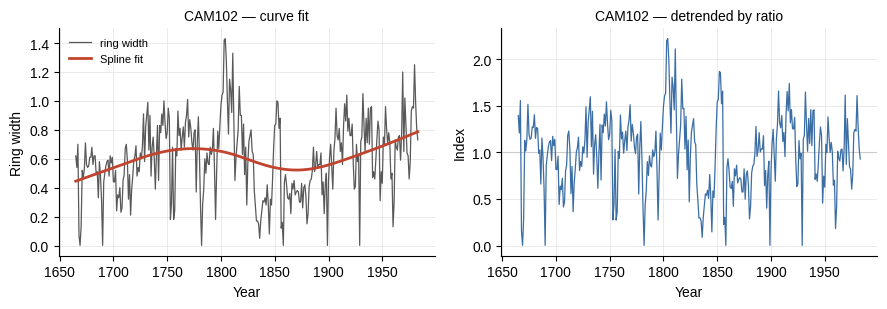

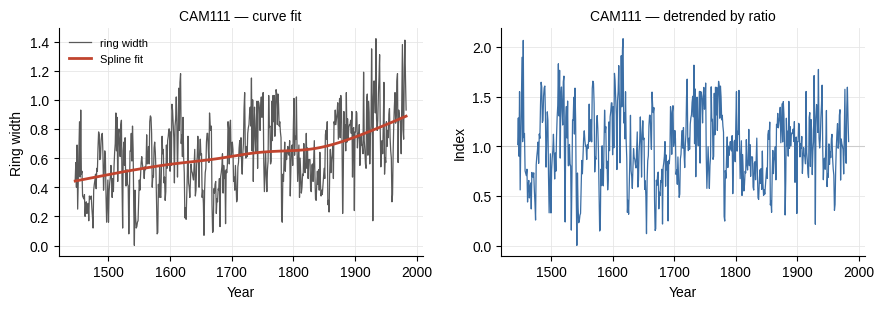

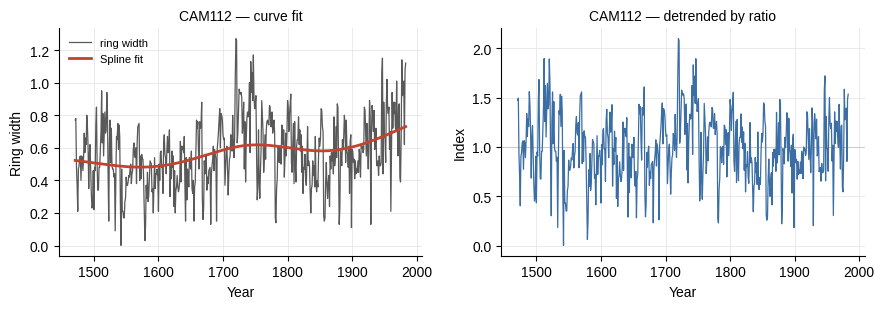

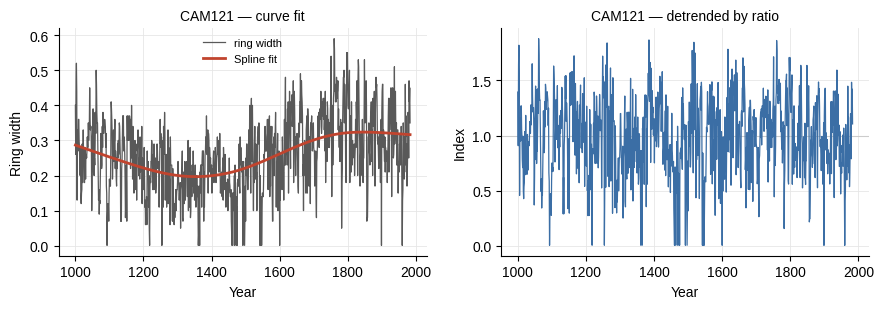

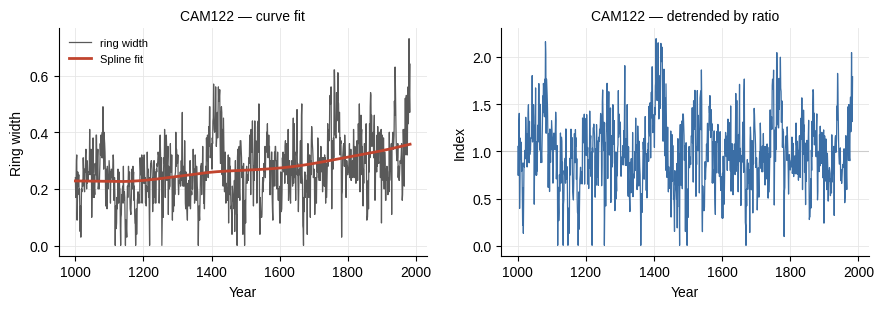

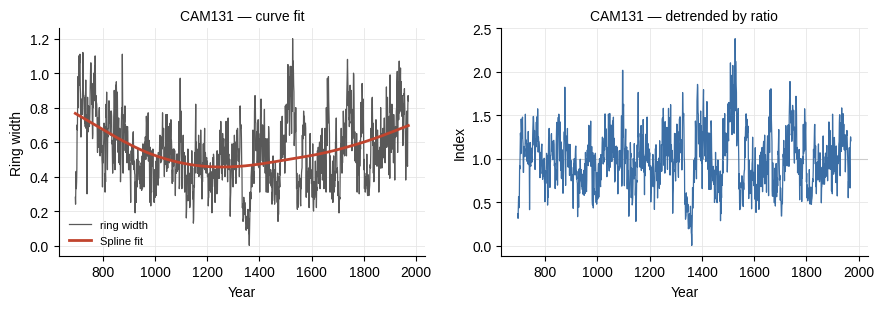

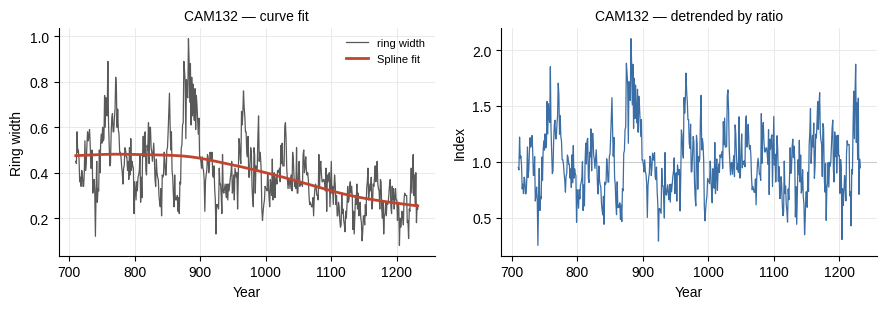

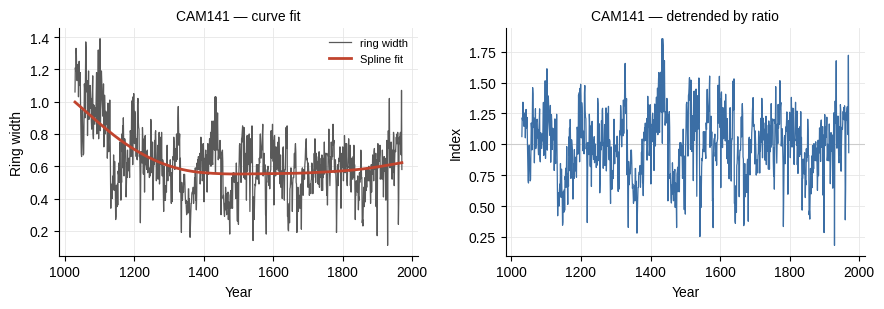

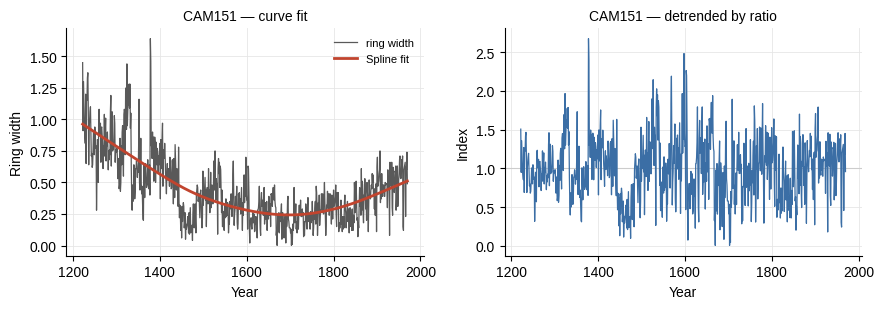

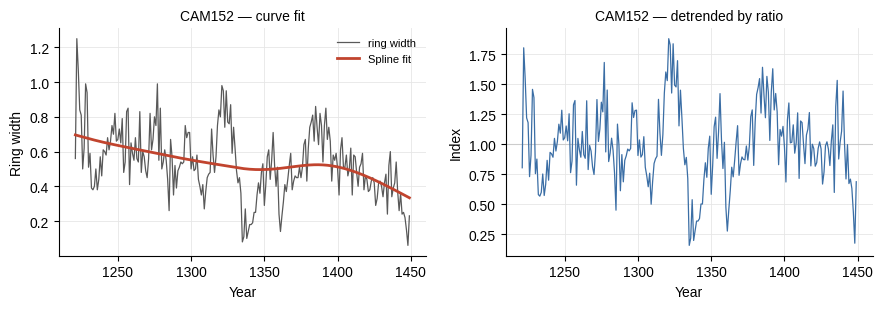

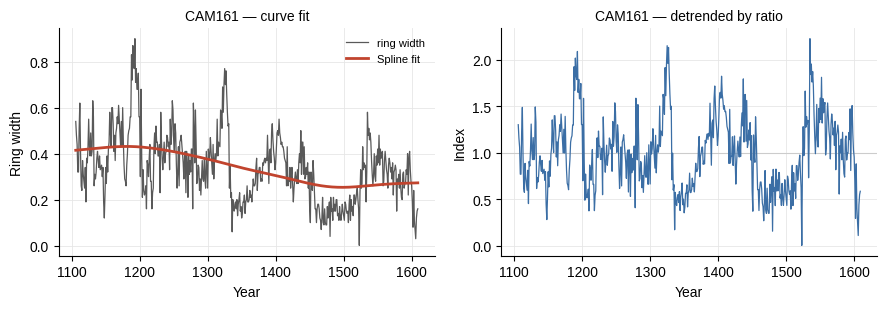

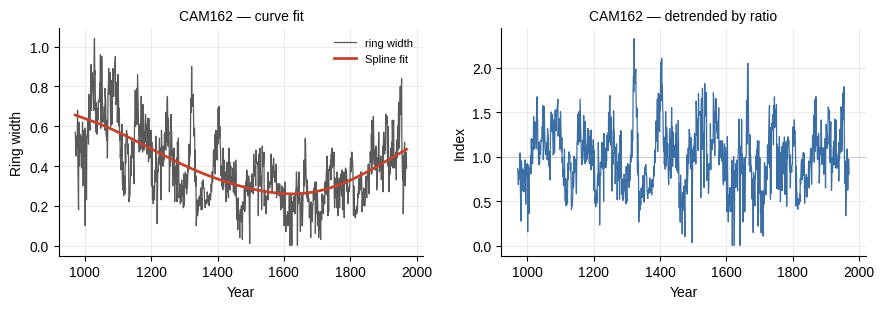

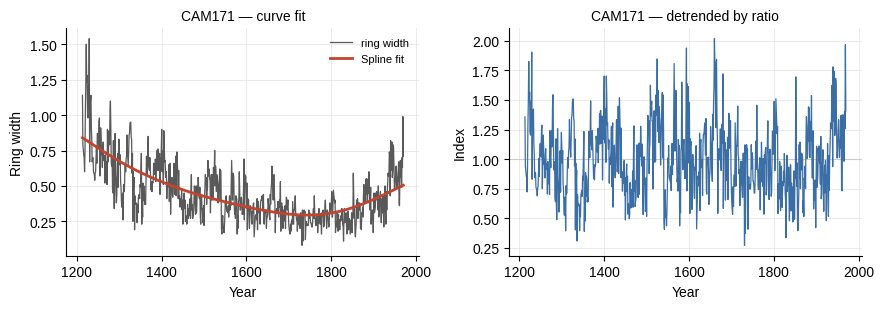

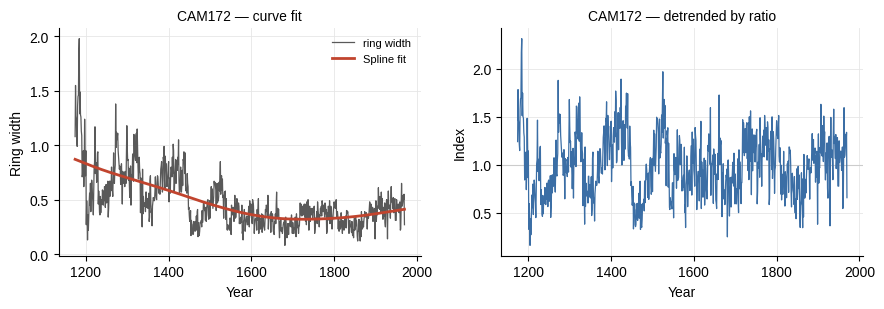

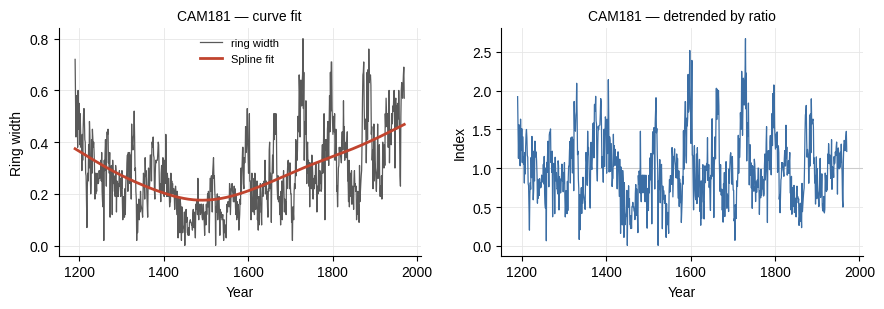

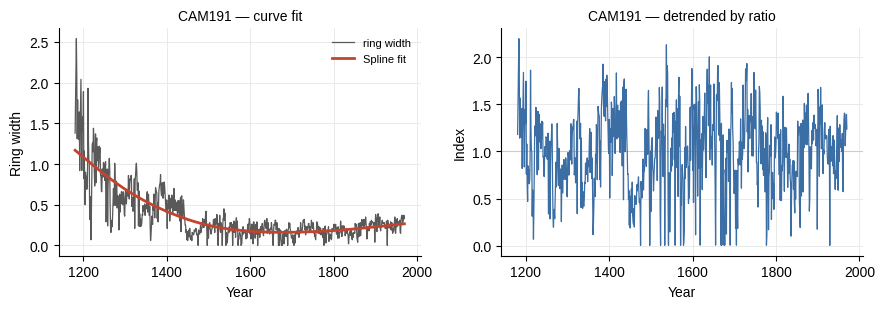

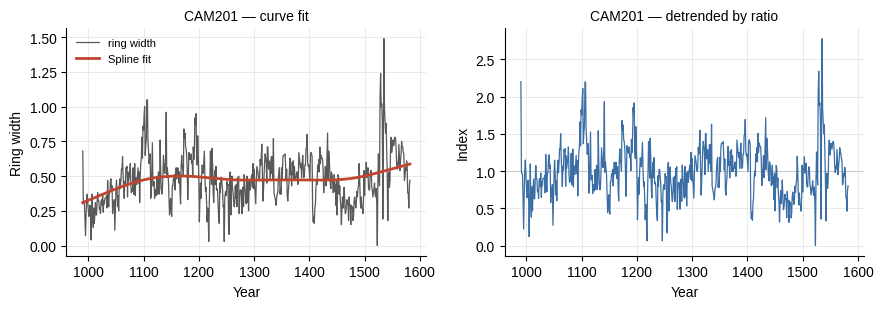

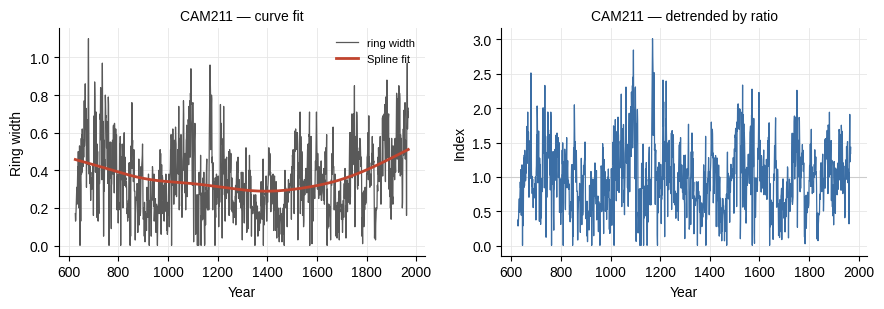

        CAM011    CAM021    CAM031    CAM032    CAM041    CAM042    CAM051  \
Year                                                                         
626        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
627        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
628        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
629        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
630        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
...        ...       ...       ...       ...       ...       ...       ...   
1979  0.995475  1.034977  0.478793  1.040669  1.214204  1.190500  1.426808   
1980  1.118064  1.451564  1.115656  1.138512  1.758599  1.543071  2.057170   
1981  1.190639  1.400113  0.998377  0.930920  1.221989  1.325492  1.830883   
1982  1.163919  1.226206  1.098160  1.197020  1.634449  1.392391  1.432169   
1983  1.681205  1.395643  0.764778  0.974028  1.852471  1.388306

In [5]:
ca533_rwi = dpl.detrend(ca533, fit="Spline", method="ratio", plot=True)
print(ca533_rwi)

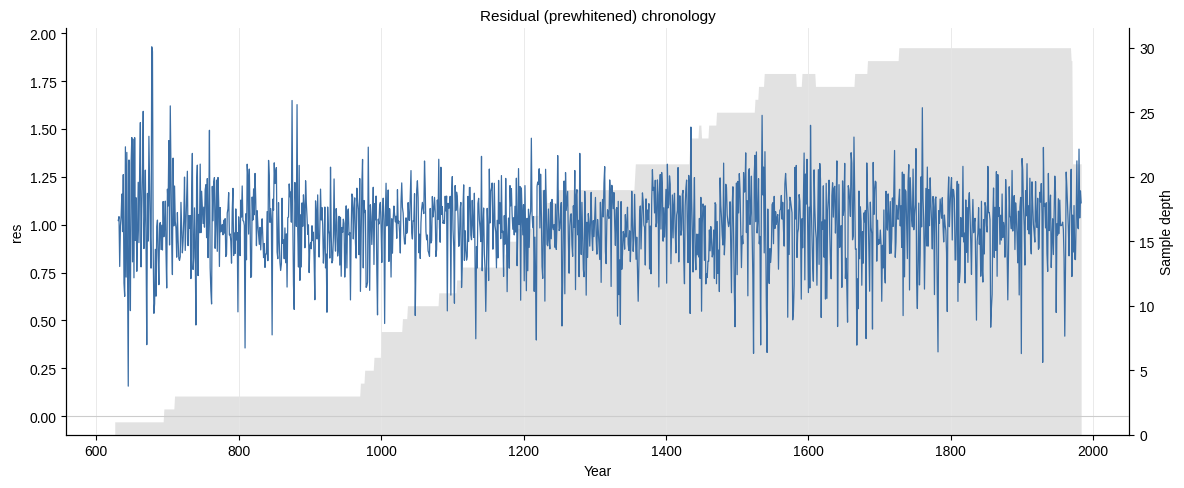

           std       res  samp_depth
Year                                
626   0.371562       NaN           1
627   0.284366       NaN           1
628   0.306488       NaN           1
629   0.416286       NaN           1
630   0.482406       NaN           1
...        ...       ...         ...
1979  1.053242  0.979058          21
1980  1.455173  1.394617          21
1981  1.252329  1.035276          21
1982  1.362052  1.176563          21
1983  1.314605  1.114135          21

[1358 rows x 3 columns]


In [6]:
ca533_crn = dpl.chron(ca533_rwi, biweight=True, prewhiten=True, plot=True)
print(ca533_crn)

In [7]:
dpl.xdate(ca533_rwi, prewhiten=True, corr="Spearman", slide_period=40, bin_floor=100, p_val=0.05, show_flags=True)

Flags for CAM011
  [A] not significant: 1900-1939, 1920-1959, 1940-1979
  [B] better at a lag:
      Segment       High  -10   -9   -8   -7   -6   -5   -4   -3   -2   -1    0   +1   +2   +3   +4   +5   +6   +7   +8   +9  +10
         1900-1939   +1 -0.16  0.10 -0.29  0.22  0.10 -0.10  0.05  0.10 -0.07 -0.12  0.12  0.27 -0.19  0.07 -0.09 -0.16  0.13 -0.20  0.25 -0.31 -0.08
         1920-1959   +8 -0.12  0.20 -0.28  0.20  0.23 -0.01  0.13 -0.02  0.01 -0.19  0.21  0.10  0.05  0.00 -0.12 -0.21  0.25 -0.18  0.30 -0.43  0.07
         1940-1979   -6  0.07  0.03 -0.21 -0.19  0.30  0.21 -0.00 -0.26 -0.17 -0.14  0.20  0.02  0.16 -0.14  0.11                                    

Flags for CAM031
  [A] not significant: 1800-1839
  [B] better at a lag:
      Segment       High  -10   -9   -8   -7   -6   -5   -4   -3   -2   -1    0   +1   +2   +3   +4   +5   +6   +7   +8   +9  +10
         1800-1839   -8 -0.03  0.06  0.42 -0.05 -0.34 -0.14 -0.03  0.03  0.27  0.07  0.25 -0.16  0.04 -0.08  0.12  0.17  

{'seg_corr':          700-739   720-759   740-779   760-799   780-819   800-839   820-859  \
 CAM011       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM021       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM031       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM032       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM041       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM042       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM051       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM061       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM062       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM071       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM072       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 CAM081       Na

In [8]:
# Writing a Tucson .crn chronology now requires site metadata, supplied as a
# SiteMetadata (or a plain dict). Other formats (rwl, csv, txt) don't need it.
meta = dpl.SiteMetadata(
    site_id="CA533", site_name="Campito Mountain",
    species_code="PILO", species_name="Pinus longaeva",
    country_region="USA-California", elevation_m=3400,
    latitude=37.5, longitude=-118.23, investigators="Graybill, D.A.")
dpl.writers(ca533_crn, "CA533", "crn", header=meta)

Writing to CA533.crn
Done.


NB: with series_x=True, positive lags indicate missing rings in the series


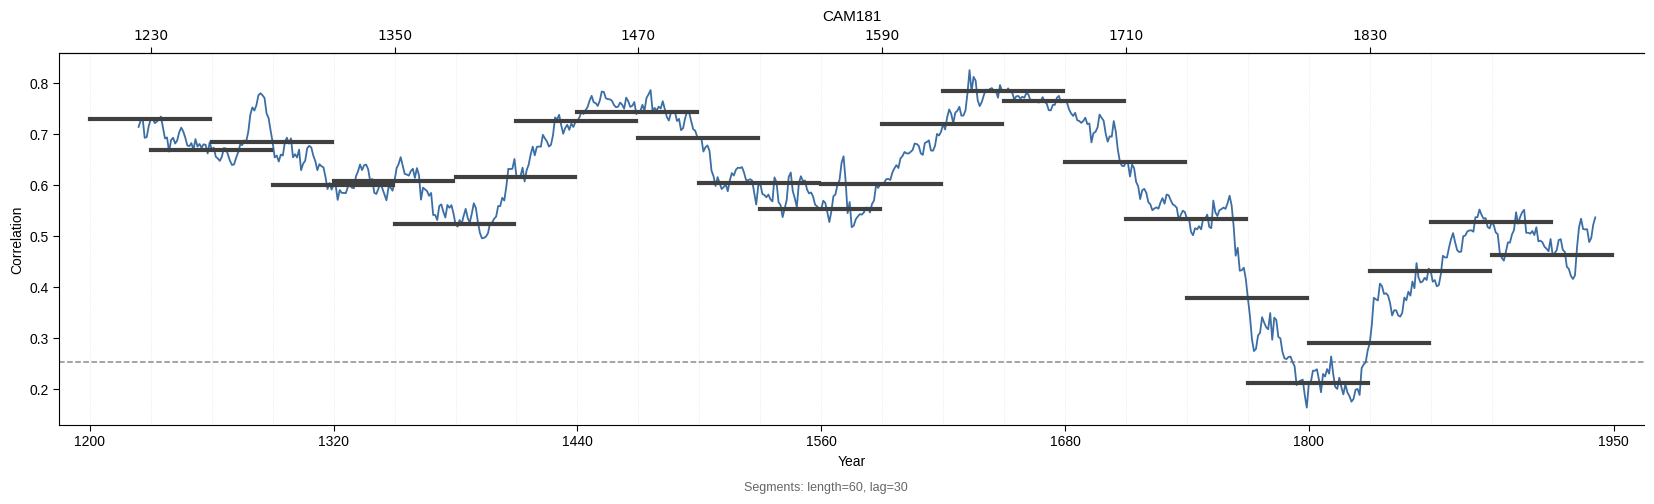

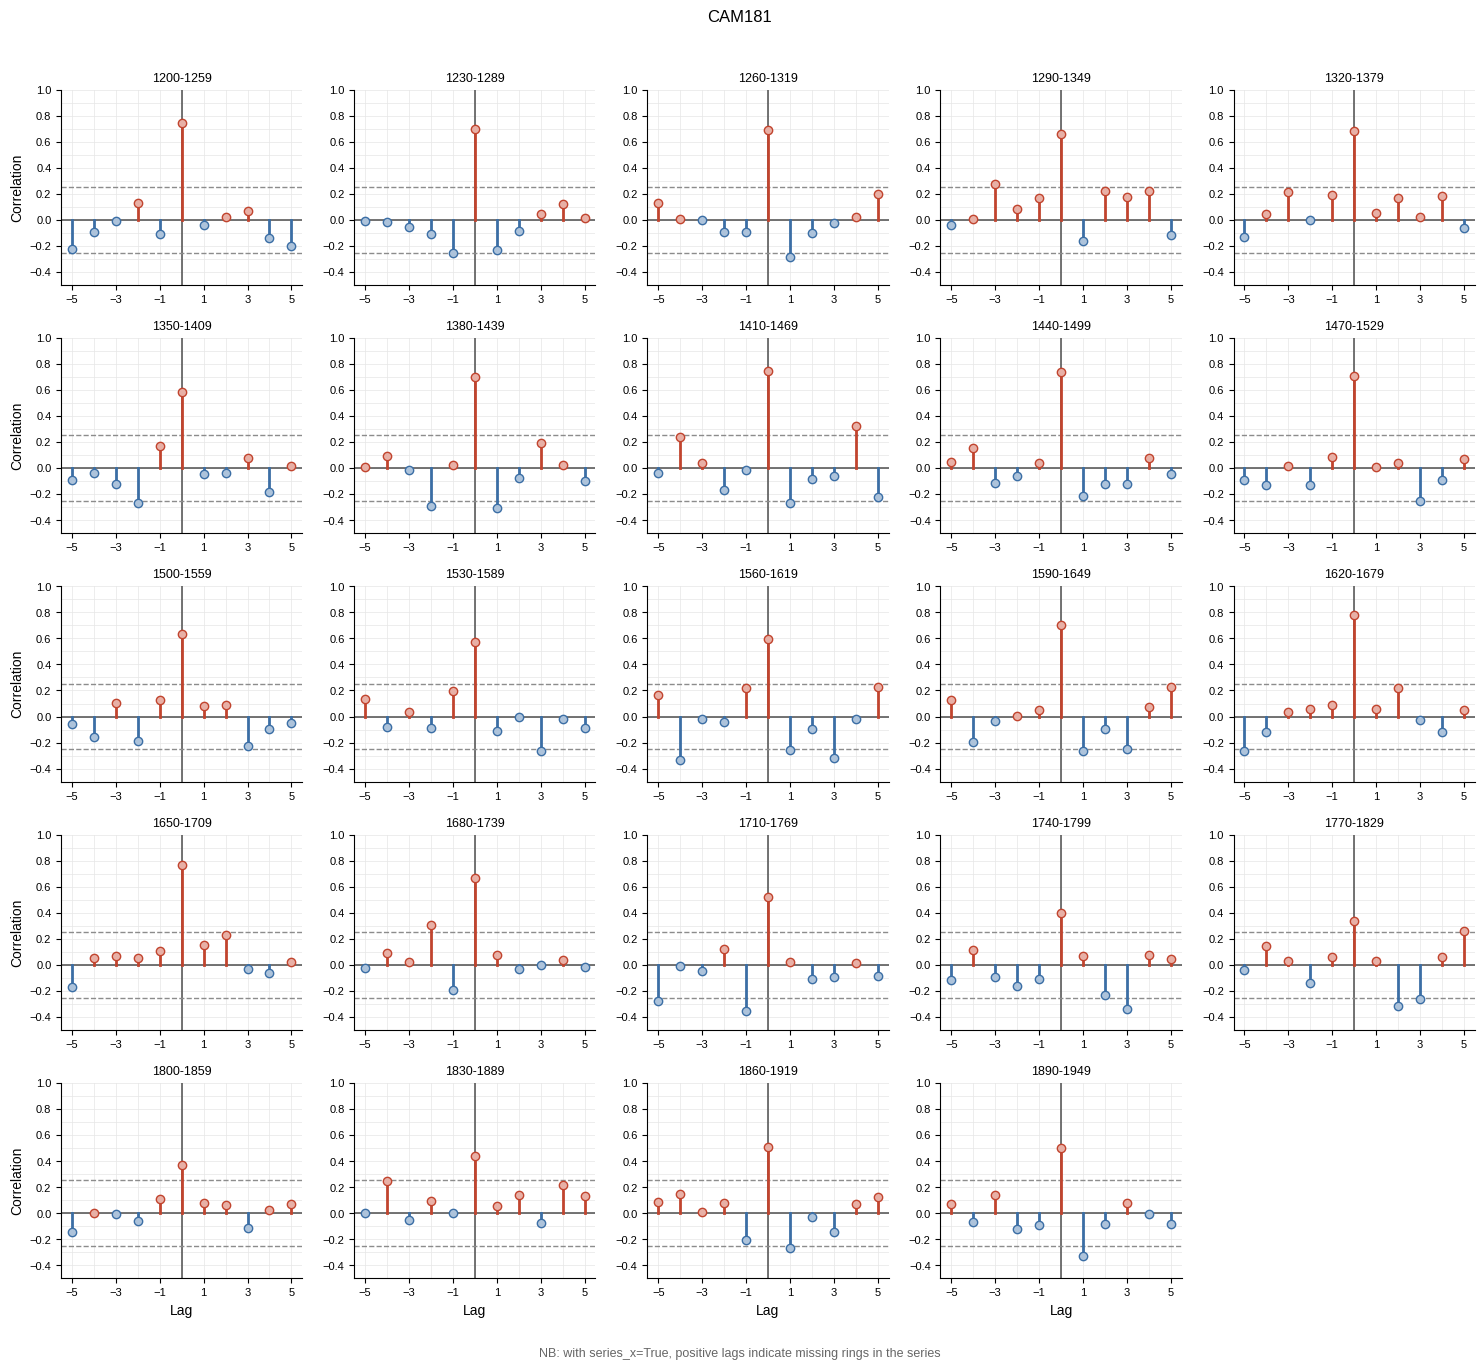

{'moving_corr': 1224    0.713754
 1225    0.726035
 1226    0.731259
 1227    0.692248
 1228    0.693804
           ...   
 1937    0.512920
 1938    0.487691
 1939    0.495527
 1940    0.522034
 1941    0.536149
 Length: 718, dtype: float64,
 'seg_corr': 660-719           NaN
 690-749           NaN
 720-779           NaN
 750-809           NaN
 780-839           NaN
 810-869           NaN
 840-899           NaN
 870-929           NaN
 900-959           NaN
 930-989           NaN
 960-1019          NaN
 990-1049          NaN
 1020-1079         NaN
 1050-1109         NaN
 1080-1139         NaN
 1110-1169         NaN
 1140-1199         NaN
 1170-1229         NaN
 1200-1259    0.729425
 1230-1289    0.669241
 1260-1319    0.683301
 1290-1349    0.599944
 1320-1379    0.608447
 1350-1409    0.522645
 1380-1439    0.616227
 1410-1469    0.725257
 1440-1499    0.742540
 1470-1529    0.692192
 1500-1559    0.602890
 1530-1589    0.552098
 1560-1619    0.601389
 1590-1649    0.719311
 1620-167

In [9]:
dpl.series_corr(ca533_rwi, "CAM181", prewhiten=True, corr="Spearman", seg_length=60, bin_floor=60, p_val=0.05, make_plot=True)

In [10]:
# Variance-stabilized chronology: rescale the mean chronology by the
# effective independent sample size (from the running interseries
# correlation, rbar). chron_stabilized() does the Neff adjustment that
# older examples computed by hand.
ca533_vsc = dpl.chron_stabilized(ca533_rwi)
print(ca533_vsc)

Generating variance stabilized chronology...



SUCCESS!

           vsc  samp_depth
Year                      
626   0.582487           1
627   0.524878           1
628   0.539494           1
629   0.612036           1
630   0.655720           1
...        ...         ...
1979  1.051662          21
1980  1.443021          21
1981  1.245512          21
1982  1.352349          21
1983  1.306150          21

[1358 rows x 2 columns]
